**Linear Regression Model**

Train size (ohne Weihnachten/Silvester/Muttertag): (1360, 25)
Test size                                      : (381, 25)

=Metrics
MSE          : 9142337.36
RMSE         : 3023.63
R²           : 0.7685
MAE          : 2311.06
Relative MSE : 0.2544
MAPE         : 21.84%


,Datum,Ist,Vorhersage
1370,2024-11-01,10986.60,10064.631619
1371,2024-11-02,15423.80,11255.798677
1372,2024-11-03,9494.20,11879.510860
1373,2024-11-04,3354.00,5400.605863
1374,2024-11-05,5702.30,5241.672334
1375,2024-11-06,4973.30,5253.128477
1376,2024-11-07,5935.70,5308.339872
1377,2024-11-08,9181.20,9293.754889
1378,2024-11-09,14831.50,10504.666307
1379,2024-11-10,12205.60,10687.171689



Weihnachten im Testset (24.12.):


,Datum,Ist,Vorhersage
1423,2024-12-24,8.6,24.866667



Silvester im Testset (31.12.):


,Datum,Ist,Vorhersage
1430,2024-12-31,46032.2,30177.766667



Muttertag im Testset:


,Datum,Ist,Vorhersage
1561,2025-05-11,40176.1,29589.666667


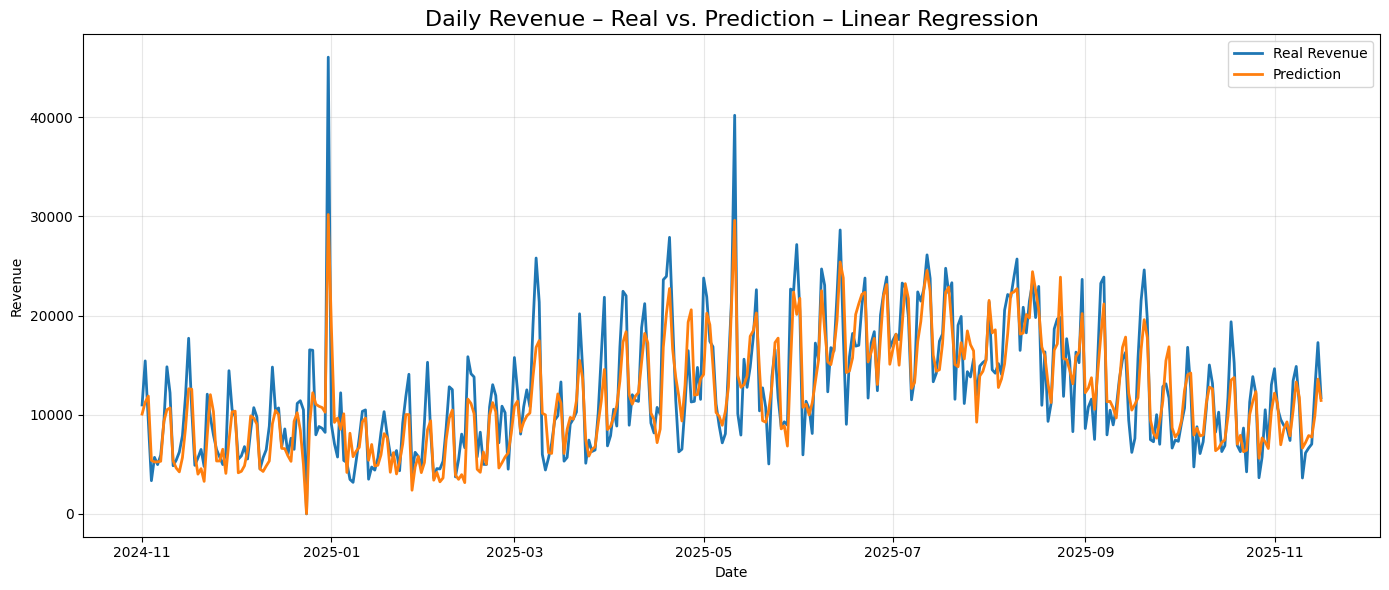

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from helper_functions import is_christmas,is_mothers_day,is_special_day,mothers_day,is_silvester,holiday_average_last_3_years


# Load Data
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Remove columns containing target variable parts
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Set target
target = "Tagesumsatz Restaurant"

# Create lag features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag3"] = df[target].shift(3)
df["lag7"] = df[target].shift(7)
df["lag14"] = df[target].shift(14)
df["lag21"] = df[target].shift(21)
df["lag28"] = df[target].shift(28)
df["lag30"] = df[target].shift(30)

# Create more date-related features
df["month"] = df["Datum"].dt.month
df["dayofyear"] = df["Datum"].dt.dayofyear
df["quarter"] = df["Datum"].dt.quarter
df["weekofyear"] = df["Datum"].dt.isocalendar().week.astype(int)
df["weekday"] = df["Datum"].dt.weekday

# Create Rolling Window features
df["roll_mean_7"] = df[target].shift(1).rolling(7).mean()
df["roll_mean_14"] = df[target].shift(1).rolling(14).mean()
df["roll_mean_28"] = df[target].shift(1).rolling(28).mean()

df["roll_std_7"] = df[target].shift(1).rolling(7).std()
df["roll_std_14"] = df[target].shift(1).rolling(14).std()

# Clean NAs
df = df.dropna().reset_index(drop=True)

# Select feature columns and create X, y
num_cols = df.select_dtypes(include=["number"]).columns
cols_to_exclude = ["Tagesumsatz Restaurant", "Restaurant", "Terrasse"]
feature_cols = [c for c in num_cols if c not in cols_to_exclude]

X = df[feature_cols]
y = df[[target]]

# Time-based Train/Test-Split
split_date = pd.Timestamp("2024-11-01")
train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]


# Remove special days from training as they're outliers
train_dates = df.loc[train_mask, "Datum"]
special_mask_train = train_dates.apply(is_special_day)

X_train = X_train[~special_mask_train]
y_train = y_train[~special_mask_train]

print("Train size (ohne Weihnachten/Silvester/Muttertag):", X_train.shape)
print("Test size                                      :", X_test.shape)

# Standardizing X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)


# Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled.ravel())

# Make predictions and transform back
y_pred_scaled = model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = y_test.values.ravel()

# Adjust special days forecast 
y_pred_adjusted = y_pred.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# Compute metrics
mse = mean_squared_error(y_test_original, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred_adjusted)
mae = mean_absolute_error(y_test_original, y_pred_adjusted)

# naive baseline: yesterday's value (lag1)
y_naive = df.loc[test_mask, "lag1"].values

mask_valid = ~pd.isna(y_naive)
y_true_rel = y_test_original[mask_valid]
y_pred_rel = y_pred_adjusted[mask_valid]
y_naive_rel = y_naive[mask_valid]

mse_model = mean_squared_error(y_true_rel, y_pred_rel)
mse_naive = mean_squared_error(y_true_rel, y_naive_rel)
relative_MSE = mse_model / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test_original, y_pred_adjusted)

print("\n=Metrics")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# Results table
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test_original,
    "Vorhersage": y_pred_adjusted
})

display(results.head(20))

# Show special days explicitely
print("\nWeihnachten im Testset (24.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 24)])

print("\nSilvester im Testset (31.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 31)])

print("\nMuttertag im Testset:")
results_mothers = results[results["Datum"].apply(lambda d: d == mothers_day(d.year))]
display(results_mothers)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(results["Datum"], results["Ist"], label="Real Revenue", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Prediction", linewidth=2)

plt.title("Daily Revenue – Real vs. Prediction – Linear Regression", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# Helper Class for specially designed CrossValidator suited for 7-day forecast

from sklearn.model_selection import BaseCrossValidator

# Separate class for cross-validation
class SevenDayForecastCV(BaseCrossValidator):
    """
    Expanding-window time-series CV splitter
    where each test set is exactly `horizon` steps long.
    """

    def __init__(self, n_splits=5, horizon=7):
        self.n_splits = n_splits
        self.horizon = horizon

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        horizon = self.horizon

        # training end points — equally spaced
        split_points = np.linspace(
            start=horizon,
            stop=n_samples - horizon,
            num=self.n_splits + 1,
            dtype=int
        )[1:]

        for train_end in split_points:
            train_idx = np.arange(train_end)
            test_idx = np.arange(train_end, train_end + horizon)
            yield train_idx, test_idx

**Ridge Model with Cross-Validation**

Fitting 7 folds for each of 20 candidates, totalling 140 fits
Best Params: {'model__fit_intercept': True, 'model__alpha': np.float64(1.623776739188721)}
Best CV MSE: 4922883.737904015

Metrics
MSE          : 9137520.90
RMSE         : 3022.83
R²           : 0.7686
MAE          : 2310.14
Relative MSE : 0.2542
MAPE         : 21.83%


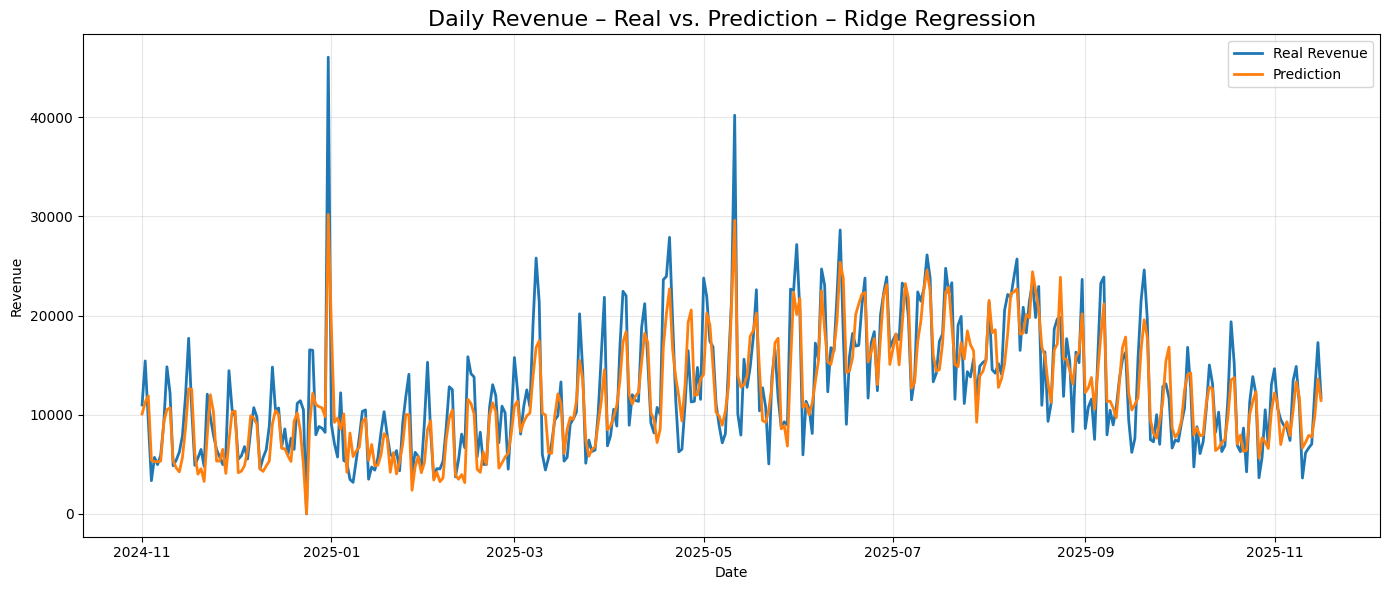

In [7]:
# Ridge model using CV

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# Pipeline: Scaling + Ridge Regression
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# Hyperparameter search space
param_distributions = {
    "model__alpha": np.logspace(-4, 4, 20),  # wide range
    "model__fit_intercept": [True, False]
}

cv = SevenDayForecastCV(n_splits=7, horizon=7)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=72,
    refit=True,
    verbose=1,
)

# Target scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

search.fit(X_train_scaled, y_train.values.ravel())
best_model = search.best_estimator_

print("Best Params:", search.best_params_)
print("Best CV MSE:", -search.best_score_)

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_test_original = y_test.values.ravel()

# Adjust for special days
y_pred_adjusted = y_pred.copy()
test_dates = df.loc[test_mask, "Datum"].values
for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# Compute Metrics
mse = mean_squared_error(y_test_original, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred_adjusted)
mae = mean_absolute_error(y_test_original, y_pred_adjusted)

# naive baseline: yesterday's value (lag1)
y_naive = df.loc[test_mask, "lag1"].values

mask_valid = ~pd.isna(y_naive)
y_true_rel = y_test_original[mask_valid]
y_pred_rel = y_pred_adjusted[mask_valid]
y_naive_rel = y_naive[mask_valid]

mse_model = mean_squared_error(y_true_rel, y_pred_rel)
mse_naive = mean_squared_error(y_true_rel, y_naive_rel)
relative_MSE = mse_model / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test_original, y_pred_adjusted)

print("\nMetrics")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# Plot
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test_original,
    "Vorhersage": y_pred_adjusted
})

plt.figure(figsize=(14, 6))
plt.plot(results["Datum"], results["Ist"], label="Real Revenue", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Prediction", linewidth=2)

plt.title("Daily Revenue – Real vs. Prediction – Ridge Regression", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()